In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [7]:
import cv2

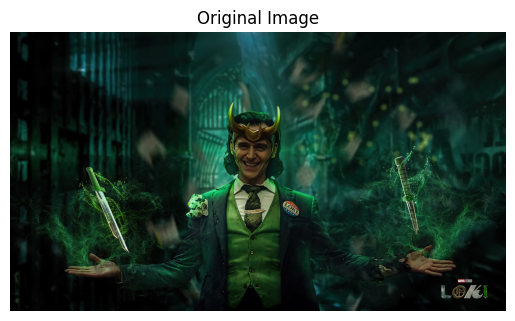

In [10]:
image = cv2.imread("C:\\Users\\SUYASH\\OneDrive\\Pictures\\loki 1.jpg")

#Convert BGR -> RGB (Imp)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

#Show image
plt.imshow(image)
plt.title("Original Image")
plt.axis('off')
plt.show()

In [12]:
#Get shape
h, w, c = image.shape

#Reshape into 2D array (pixels, 3)
pixels = image.reshape(-1,3)

print(pixels.shape) #(num_pixels, 3)


(8294400, 3)


In [13]:
pixels = pixels/255.0

In [22]:
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(pixels)
    inertia.append(kmeans.inertia_)
    labels = kmeans.labels_
    centroids = kmeans.cluster_centers_

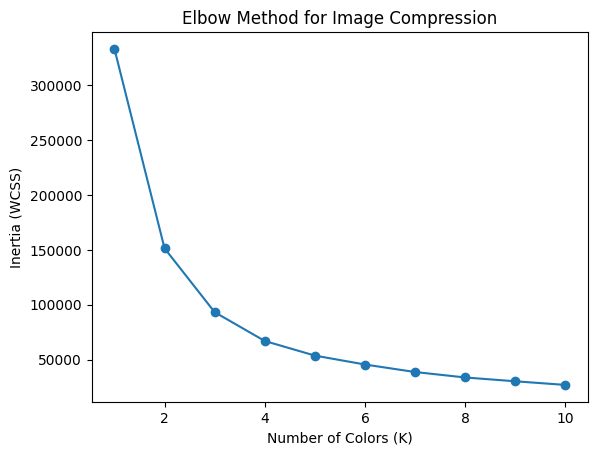

In [23]:
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Colors (K)")
plt.ylabel("Inertia (WCSS)")
plt.title("Elbow Method for Image Compression")
plt.show()

In [24]:
#Reconstruct Compressed Image
compressed_pixels = centroids[labels]

#Reshape back to image
compressed_image = compressed_pixels.reshape(h,w,3)

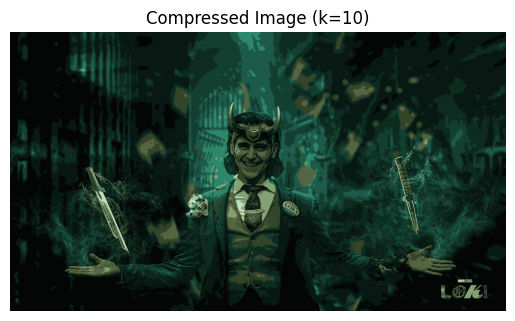

In [25]:
#Show Compressed Image
plt.imshow(compressed_image)
plt.title(f"Compressed Image (k={k})")
plt.axis('off')
plt.show()

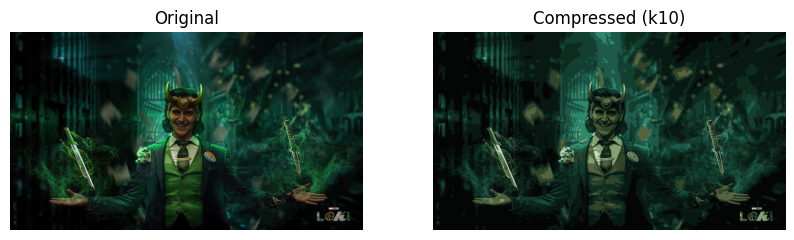

In [26]:
#Compare original vs Compressed
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Original")
plt.axis('Off')

plt.subplot(1,2,2)
plt.imshow(compressed_image)
plt.title(f"Compressed (k{k})")
plt.axis('off')

plt.show()